In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [1]:
import os.path as osp
import matplotlib.pyplot as plt
#from tqdm.notebook import tqdm
from tqdm import tqdm
import numpy as np
import networkx as nx
from scipy import sparse, stats
from numpy import inf
import numpy
import torch 
device = torch.device("cpu")

from scipy.sparse import identity
from scipy.sparse import csgraph
from scipy import linalg
from scipy.sparse import csr_matrix
from scipy.sparse import linalg
import ipynb.fs.full.utils.BarbellGraph as BGraph

from LocalSpectralParallel import effective_resistance_akp_parallel
from joblib import Parallel, delayed
from ipynb.fs.full.SpectralSparsifier import EffectiveResistance, LocalEffectiveResistance

Cpu count:  12


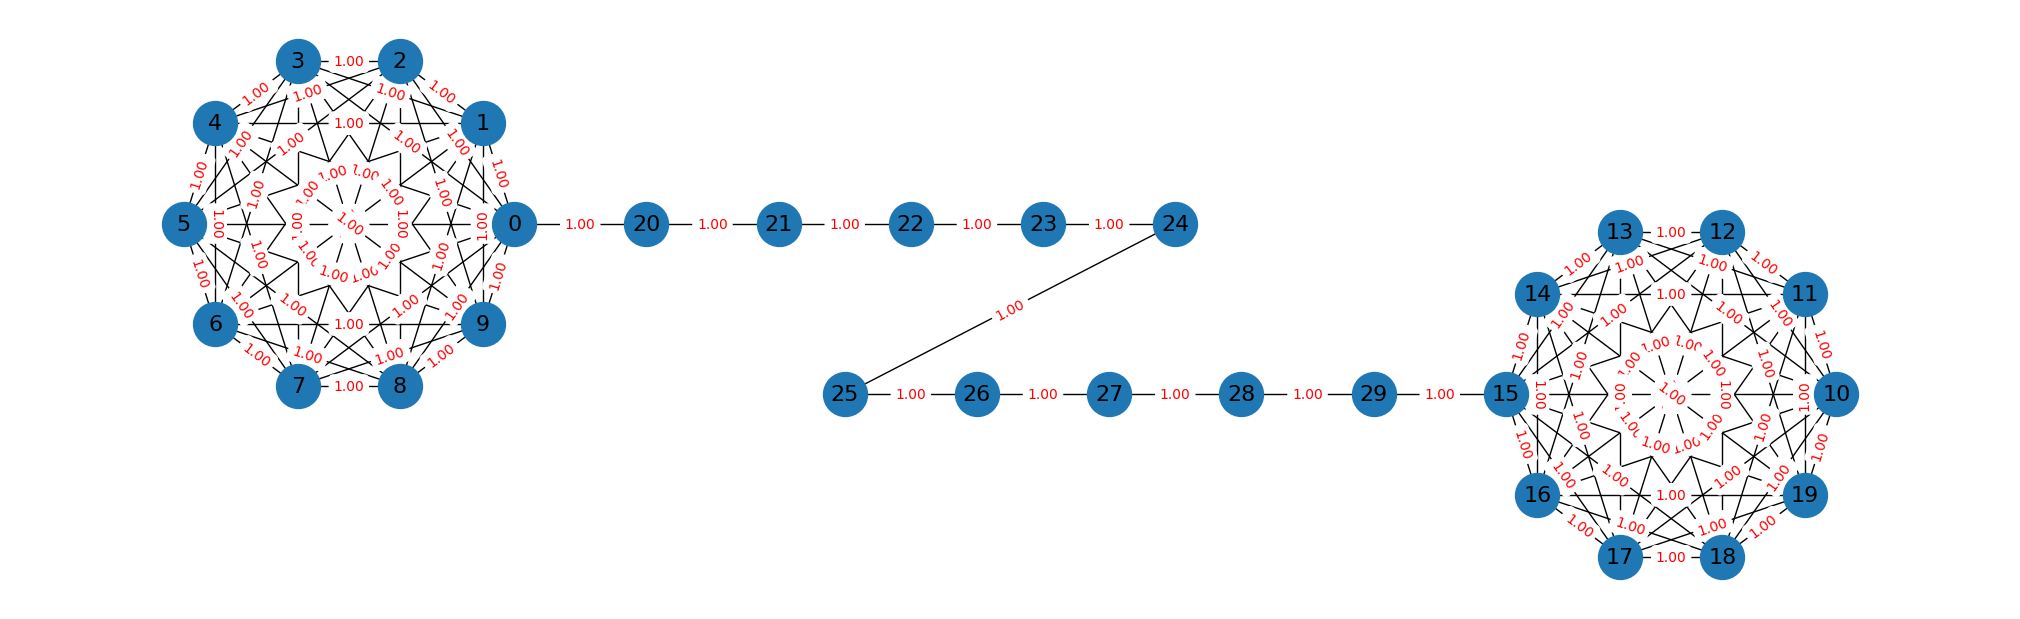

In [2]:
DEBUG=True
DRAW=True

if DEBUG:
    G, pos = BGraph.generate_barbell(10,10)

    # if DRAW:
    #     BGraph.draw_graph(G,pos)

    X=np.zeros((len(pos),2))
    for key,value in pos.items():
        X[key]=value

    minx=np.min(X,0)
    X=X-minx
    minx=np.min(X,0)
    X_pos={key:X[key] for key,value in pos.items()}

    if DRAW:
        BGraph.draw_graph(G,X_pos)

# Overall ALGORITHM  2

### Step 1: Effective Resistance Computation

Ideally use some sort of fast parallel approximation of Effective Resistance Computation

### Step 2: Get Maximum Spanning Tree using Pe = WeRe of edges

Compute Maximum Spanning Tree to get the base sparsifier

<font color='red'> Option 1: </font> Sparsify first and then incrementally add edge with high $P_e$ to ensure connectivity

### Step 3: Using the Spanning tree as base, use submodular selection of new edges

Refine Sparsifer with respect to each vertex select subset of neighbors

<font color='red'> Option 1: </font> impose some sort of order among neighbors to maintain degree balance


### Step 1: Effective Resistance Computation

In [2]:
def ERprob(G, compute='exact'):
    Adj = nx.adjacency_matrix(G)
    start_nodes, end_nodes, weights = sparse.find(sparse.tril(Adj))
    if DEBUG: print("Computing edge resistances: ... ",compute)
    
    if compute=='exact':
        Re=EffectiveResistance(G)
        Re = np.maximum(0, Re[start_nodes, end_nodes].toarray())
    else:
        Re=LocalEffectiveResistance(G, Adj, method=None, eps=0.4, lmbda=0.1)
    
    if DEBUG: print("Finished computing resistances:")

    N=Adj.shape[0]

    # Calculate the new weights.
    weights = np.maximum(0, weights)
    
    Pe = weights * Re
    Pe = Pe / np.sum(Pe)    
    Pe = np.squeeze(Pe)
    
    ERW = sparse.csc_matrix((Pe, (start_nodes, end_nodes)),shape=(N, N))    
    ERW = ERW + ERW.T #making symmetric

    return Pe, ERW, Adj

#Pe, ERW, Adj = ERprob (G, compute='approx')

### Step 2 : Create Maximum Spanning Tree as base

#### Create a the graph using effective ressistance based edge probabilty as weight

In [ ]:
def MSTbaseGraph(G):
    
    Pe, ERW, Adj = ERprob (G, compute='approx')
    #ER_G = nx.from_scipy_sparse_matrix(ERW)
    ER_G = nx.from_scipy_sparse_array(ERW) #for networkx 3.0
    
    mst=nx.maximum_spanning_edges(ER_G, data=True)
    
    sp_edges=list(mst)
    
    ST_G = nx.Graph()
    ST_G.add_edges_from(sp_edges)
    
    return ER_G, ST_G

if DEBUG:
    ER_G, ST_G = MSTbaseGraph(G)
    if DRAW:
        BGraph.draw_graph(ER_G,X_pos)
        BGraph.draw_graph(ST_G,X_pos)

### Step 3:  Submodular Sparsification with Effective Resistance weight

In [3]:
from CustomSubmodularSelector import CustomSubmodularSelector as CustomFacilityLocationSelection
from CustomSpectralSelector import CustomSpectralSelector as SqrtFeatureBasedSelection
from CustomFeatureBased import FeatureBasedSelection as CustomFeatureBasedSelection


from apricot import BaseSelection
from apricot import FeatureBasedSelection, MaxCoverageSelection, FacilityLocationSelection
from apricot import GraphCutSelection, SumRedundancySelection, SaturatedCoverageSelection, MixtureSelection

In [ ]:
def LocalKSparsifySpectral(G, X, K):
    
    ER_G, ST_G = MSTbaseGraph(G)
    H = ST_G.copy()
    nodes=list(ER_G.nodes())
    H.add_nodes_from(nodes) #isolated nodes missed by MST
    
    pbar = tqdm(total=len(nodes))
    pbar.set_description(f'Nodes:')
    
    for u in nodes:    
        node_set=list(ER_G.neighbors(u))        
        current_set=list(H.neighbors(u))
        
#         print("*"*100)
#         print("U: ",u)
#         print("Neighbor set: ", len(node_set), node_set)
#         print("Current Neighbor set: ", len(current_set),current_set)
        
        to_select=K-(len(current_set))
        
        if to_select<=0:
            pbar.update(1)        
            continue
            
        remain=list(set(node_set)-set(current_set))            
        
        if len(remain)<=to_select:
            node_ranks=remain            
        else:   
            
            weights=np.array([ER_G[u][v]["weight"] for v in node_set])
            
            weights = weights / sum(weights)             
            weights=np.append(weights,1.0)
            
            #print(weights)
            
            node_set.append(u)
            current_set.append(u)
        
            node2index={node_set[i]:i for i in range(len(node_set))}
            index2node={i:node_set[i] for i in range(len(node_set))}      
            
            
            X_f=X[node_set]
            #X_f=np.multiply(X_f, weights[:, np.newaxis])
            
            model = SubFunction(to_select,
                                initial_subset=[node2index[i] for i in current_set], 
                                optimizer='stochastic',
                                #metric='euclidean',
                               )
            model.fit(X_f)
            
            ranks = model.ranking            
            node_ranks=[index2node[i] for i in ranks]
        
        
        for v in node_ranks:
            H.add_edge(u,v, weight=ER_G[u][v]["weight"])
            
        pbar.update(1)        
    pbar.close()
            
    return H

if DEBUG:
    print("Sparse Graph:.....")

    K=2
    H = LocalKSparsifySpectral(G, X, K)

    if DRAW:
        BGraph.draw_graph(H,X_pos)
    print(len(H.edges))

# Overall ALGORITHM

### Step 1: Effective Resistance Computation

Ideally use some sort of fast parallel approximation of Effective Resistance Computation

### Step 2: Use submodular selection of new edges

Refine Sparsifer with respect to each vertex select subset of neighbors

<font color='red'> Option 1: </font> impose some sort of order among neighbors to maintain degree balance

### Step 3: Use Pe = WeRe of edges to connect 

Sparsify first and then incrementally add edge with high $P_e$ to ensure connectivity



### Step 1 & Step 2

In [6]:
def LocalKSpectralSubmodular(G, X, K):
    
    Pe, ERW, Adj = ERprob (G, compute='approx')
    #ER_G = nx.from_scipy_sparse_matrix(ERW)
    ER_G = nx.from_scipy_sparse_array(ERW) #for networkx 3.0
        
    H = nx.Graph()
    nodes=list(ER_G.nodes())
    H.add_nodes_from(nodes) #isolated nodes missed by MST
    
    pbar = tqdm(total=len(nodes))
    pbar.set_description(f'Nodes')
    
    for u in nodes:    
        node_set=list(ER_G.neighbors(u))        
        current_set=list(H.neighbors(u))
        
#         print("*"*100)
#         print("U: ",u)
#         print("Neighbor set: ", len(node_set), node_set)
#         print("Current Neighbor set: ", len(current_set),current_set)
        
        to_select=K-(len(current_set))
        
        if to_select<=0:
            pbar.update(1)        
            continue
            
        remain=list(set(node_set)-set(current_set))            
        
        if len(remain)<=to_select:
            node_ranks=remain            
        else:   
            
            weights=np.array([ER_G[u][v]["weight"] for v in node_set])
            
            weights = weights / sum(weights)             
            weights=np.append(weights,1.0)
            
            #print(weights)
            
            node_set.append(u)
            current_set.append(u)
        
            node2index={node_set[i]:i for i in range(len(node_set))}
            index2node={i:node_set[i] for i in range(len(node_set))}      
            
            
            X_f=X[node_set]
            #X_f=np.multiply(X_f, weights[:, np.newaxis])
            
            model = SubFunction(to_select,
                                initial_subset=[node2index[i] for i in current_set], 
                                optimizer='stochastic',
                                #metric='euclidean',
                               )
            model.fit(X_f)
            
            ranks = model.ranking            
            node_ranks=[index2node[i] for i in ranks]
        
        
        for v in node_ranks:
            H.add_edge(u,v, weight=ER_G[u][v]["weight"])
            
        pbar.update(1)        
    pbar.close()
    
    return ER_G, H

# print("Sparse Graph:.....")

# K=1
# ER_G, H = LocalKSpectralSubmodular(G, X, K)
# BGraph.draw_graph(ER_G,X_pos)
# BGraph.draw_graph(H,X_pos)
# print(len(H.edges))

### Step 3: Use Pe = WeRe of edges to connect 

In [7]:
from ipynb.fs.full.ConnectivityMST import Connectivity

def SpectralSubmodularK(G, X, K):

    ER_G, H = LocalKSpectralSubmodular(G, X, K) 
    
    BGraph.draw_graph(H,X_pos)
    
    if DEBUG: print("Connecting community ...")
    T = Connectivity(ER_G, H, weight="weight", algorithm="kruskal", ignore_nan=False)
    
    return T

if DEBUG:
    K=1
    H = SpectralSubmodularK(G, X, K)

    if DRAW==True:    
        BGraph.draw_graph(H,X_pos)
    print(len(H.edges))

ModuleNotFoundError: No module named 'ipynb.fs.full.ConnectivityMST'

## Neighbor Sampling with Cosine Similarity

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
import random
from sklearn.metrics.pairwise import cosine_similarity
from typing import Callable, List, NamedTuple, Optional, Tuple, Union
from torch_geometric.utils import add_self_loops,add_remaining_self_loops
from torch_geometric.utils import remove_self_loops
import torch_sparse
from torch import Tensor
from torch_geometric.typing import SparseTensor
from torch_geometric.loader import NeighborSampler, NeighborLoader
from torch_geometric.datasets import WebKB
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.datasets import Reddit, Reddit2
from torch_geometric.datasets import CoraFull
from torch_geometric.utils import to_undirected
import os
from pathlib import Path
import os.path as osp
import matplotlib.pyplot as plt
#from tqdm.notebook import tqdm
from tqdm import tqdm
import numpy as np
import networkx as nx
from scipy import sparse, stats
from numpy import inf
import numpy
import torch 
device = torch.device("cpu")
from ipynb.fs.full.Dataset import get_data_from_dataset
from ipynb.fs.full.CosineWeightedNeighborLoader import get_data,Custom_CosineSimilarity_Sampling,NeighborSampler_,precomputing_weight_calculation,manage_dataset_directory
from torch_geometric.utils import add_self_loops,add_remaining_self_loops


Data directory:  ./Dataset/
Result directory: ./Dataset/RESULTS/

Dataset: Amherst41(1):
Number of graphs: 1
Number of features: 1193
Number of classes: 2

Data(x=[2235, 1193], edge_index=[2, 181908], y=[2235], train_mask=[2235], val_mask=[2235], test_mask=[2235])
Number of nodes: 2235
Number of edges: 181908
Average node degree: 81.39
Number of training nodes: 1341
Training node label rate: 0.60
Has isolated nodes: False
Has self-loops: False
Is undirected: True
Shifting label to non-negative


/home/muftiqur/Graph Research/Graph-Sparsification/GraphSparsification/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data directory:  ./Dataset/
Result directory: ./Dataset/RESULTS/


In [32]:
data, dataset = get_data_from_dataset("amherst41")


if len(data.y.shape) > 1:
    data.y = data.y.argmax(dim=1)        
    num_classes = torch.max(data.y).item()+1
else:
    num_classes = dataset.num_classes
if num_classes!= torch.max(data.y)+1:
    num_classes = torch.max(data.y).item()+1
    
#weight_list = precomputing_weight_calculation(data.x,data.edge_index,sizes=[8,4])

Data directory:  ./Dataset/
Result directory: ./Dataset/RESULTS/

Dataset: Amherst41(1):
Number of graphs: 1
Number of features: 1193
Number of classes: 2

Data(x=[2235, 1193], edge_index=[2, 181908], y=[2235], train_mask=[2235], val_mask=[2235], test_mask=[2235])
Number of nodes: 2235
Number of edges: 181908
Average node degree: 81.39
Number of training nodes: 1341
Training node label rate: 0.60
Has isolated nodes: False
Has self-loops: False
Is undirected: True
Shifting label to non-negative


Testing for DataLoader

In [30]:
# DEBUG = True
# data.edge_index = add_remaining_self_loops(data.edge_index)[0]
# cosine_similarity_dictionary = Custom_CosineSimilarity_Sampling(data.x, data.edge_index)
# train_neighbors = [3,3]
# train_idx = data.train_mask.nonzero(as_tuple=False).view(-1)

# train_loader = NeighborSampler_(data.edge_index, node_idx=train_idx,
#                                    sizes=train_neighbors, batch_size=1,
#                                    shuffle=True, num_workers=1,cosine_similarity_dict=cosine_similarity_dictionary)               

In [1]:
# train_neighbors = [8,4]
# train_idx = data.train_mask.nonzero(as_tuple=False).view(-1)

# train_loader = NeighborSampler_(data.edge_index, node_idx=train_idx,
#                                    sizes=train_neighbors, batch_size=16,
#                                    shuffle=True, num_workers=1,weight_list=weight_list) 

# for batch_size, n_id, adjs in train_loader:
#     print(n_id)
#     print(adjs)

In [4]:
def train_(model, data, epochs=100,split_index=None, train_neighbors=[25,10],weight_list = None):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()
    edge_index = remove_self_loops(data.edge_index)[0]
    if split_index!=None:
        print("FOR SPLIT INDEX ",split_index)
        train_idx = data.train_mask[:, split_index].nonzero(as_tuple=False).view(-1)
    else:
        train_idx = data.train_mask.nonzero(as_tuple=False).view(-1)
        
    train_loader = NeighborSampler_(edge_index, node_idx=train_idx,
                                   sizes=train_neighbors, batch_size=64,
                                   shuffle=True, num_workers=1,weight_list=weight_list) 
     
    #Need to change here.
    subgraph_loader = NeighborSampler_(edge_index, node_idx=None,
                                          sizes=[-1], batch_size=64,
                                          shuffle=False,num_workers=1,weight_list=weight_list)

    
    print("Finish Computing train_loader and subgraph Loader")
    
    x, y = data.x.to(device), data.y.to(device)
    data.train_mask.to(device)
    data.val_mask.to(device)
    data.test_mask.to(device)
    
    best_acc=0    
    for epoch in range(1,epochs+1):
        
        pbar = tqdm(total=train_idx.size(0))
        pbar.set_description(f'Epoch {epoch:02d}')
        
        total_loss = total_correct = 0
        model.train()
        for batch_size, n_id, adjs in train_loader:
            adjs = [adj.to(device) for adj in adjs]
            optimizer.zero_grad()
            out = model(x[n_id], adjs)
            #loss = F.nll_loss(out, y[n_id[:batch_size]])
            loss = criterion(out, y[n_id[:batch_size]])
            loss.backward()
            optimizer.step()
            
            total_loss += float(loss)
            total_correct += int(out.argmax(dim=-1).eq(y[n_id[:batch_size]]).sum())
            pbar.update(batch_size)

        pbar.close()

        loss = total_loss / len(train_loader)
        approx_acc = total_correct / train_idx.size(0)
        
        #print(f'Epoch: {epoch:03d}, Training Loss: {loss:.4f}, Training Accuracy: {approx_acc:.4f}')
        ####EVALUATION
        if epoch>0 and epoch % 5 == 0:
            model.eval()
            with torch.no_grad():
                out = model.inference(x, device, subgraph_loader)
            #calculate_f1_scores(data,epoch, out, data.y, split_index)
            res = out.argmax(dim=-1) == data.y
            # train_acc = int(res[data.train_mask].sum()) / int(data.train_mask.sum())
            # val_acc = int(res[data.val_mask].sum()) / int(data.val_mask.sum())
            # test_acc = int(res[data.test_mask].sum()) / int(data.test_mask.sum())
            if split_index!=None:
                train_acc = int(res[data.train_mask[:,split_index]].sum()) / int(data.train_mask[:,split_index].sum())
                val_acc = int(res[data.val_mask[:,split_index]].sum()) / int(data.val_mask[:,split_index].sum())
                test_acc = int(res[data.test_mask[:,split_index]].sum()) / int(data.test_mask[:,split_index].sum())    
            else:
                train_acc = int(res[data.train_mask].sum()) / int(data.train_mask.sum())
                val_acc = int(res[data.val_mask].sum()) / int(data.val_mask.sum())
                test_acc = int(res[data.test_mask].sum()) / int(data.test_mask.sum())

            print(f'*******Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_acc:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}, best_acc: {best_acc}*******')
            if test_acc>best_acc:
                best_acc=test_acc
    
    # best_model.eval()
    # with torch.no_grad():
    #     out = best_model.inference(x, device, subgraph_loader)
    # #calculate_f1_scores(data,epoch, out, data.y, split_index)
    # res = out.argmax(dim=-1) == data.y
    # if split_index!=None:
    #     test_accuracy = int(res[data.test_mask[:,split_index]].sum()) / int(data.test_mask[:,split_index].sum())    
    # else:
    #     test_accuracy = int(res[data.test_mask].sum()) / int(data.test_mask.sum())
    print(f"********  Test Accuracy: {best_acc}************")
    return best_acc


In [6]:
from ipynb.fs.full.Dataset import get_data_from_dataset
from ipynb.fs.full.CosineWeightedNeighborLoader import get_data,Custom_CosineSimilarity_Sampling,NeighborSampler_,precomputing_weight_calculation,manage_dataset_directory
from torch_geometric.utils import add_self_loops,add_remaining_self_loops
from ipynb.fs.full.calculate_effective_resistance import get_ER_matrix

Data directory:  ./Dataset/
Result directory: ./Dataset/RESULTS/


In [ ]:
data, dataset = get_data_from_dataset('johnshopkins55')
edge_index = remove_self_loops(data.edge_index)[0]
ER_weight = get_ER_matrix(data.x,edge_index,[8,4])

In [15]:
ER_weight_tensor = torch.tensor(ER_weight)
ER_weight_tensor

tensor([1.0000, 0.4488, 0.4009,  ..., 0.5958, 1.0000, 1.0000],
       dtype=torch.float64)

In [14]:
train_idx = data.train_mask.nonzero(as_tuple=False).view(-1)
train_loader = NeighborSampler(edge_index, node_idx=train_idx,
                                   sizes=[2,2], batch_size=64,
                                   shuffle=False, num_workers=1,weight_list=ER_weight_tensor) 
for batch_size, n_id, adjs in train_loader:
    print("HELLO WORLD")

HELLO WORLD
HELLO WORLD


In [20]:
# data, dataset = get_data_from_dataset('Minesweeper')
# edge_index = remove_self_loops(data.edge_index)[0]
# ER_weight = manage_dataset_directory(dataset.name, data) + 0.001
# cosine_weight = precomputing_weight_calculation(data.x,edge_index,[8,4]) + 0.001
# weight_list = ER_weight*cosine_weight
# weight_list

In [16]:
from ipynb.fs.full.GraphSageModel import SAGE

def GSAGEperformance(data, dataset, epochs=20, train_neighbors=[25,10],weight_list=ER_weight_tensor):
    print(dataset.num_features, dataset.num_classes,train_neighbors)  
    #data.edge_index = add_remaining_self_loops(data.edge_index)[0]
    model = SAGE(dataset.num_features, dataset.num_classes, hidden_channels=256).to(device)  
    model = train_(model, data, epochs,train_neighbors=train_neighbors,weight_list=weight_list)
    return model

In [17]:
if __name__ == '__main__':   
    train_neighbors = [2,2]
    model  = GSAGEperformance(data, dataset, epochs=250, train_neighbors=train_neighbors,weight_list=ER_weight_tensor)

3703 6 [2, 2]
Finish Computing train_loader and subgraph Loader


Evaluating: 100%|██████████| 6654/6654 [00:01<00:00, 6080.38it/s]


*******Epoch: 005, Loss: 1.7648, Train: 0.5250, Val: 0.2820, Test: 0.3310, best_acc: 0*******


Evaluating: 100%|██████████| 6654/6654 [00:01<00:00, 5471.60it/s]


*******Epoch: 010, Loss: 1.7123, Train: 0.9667, Val: 0.3760, Test: 0.3980, best_acc: 0.331*******


...

*******Epoch: 240, Loss: 0.0948, Train: 1.0000, Val: 0.7100, Test: 0.7020, best_acc: 0.709*******


Evaluating: 100%|██████████| 6654/6654 [00:00<00:00, 7121.61it/s]


*******Epoch: 245, Loss: 0.0921, Train: 1.0000, Val: 0.7060, Test: 0.6960, best_acc: 0.709*******


Evaluating: 100%|██████████| 6654/6654 [00:00<00:00, 7297.82it/s]

*******Epoch: 250, Loss: 0.0864, Train: 1.0000, Val: 0.7040, Test: 0.7010, best_acc: 0.709*******
********  Test Accuracy: 0.709************


In [96]:
cornell_acc = torch.tensor([0.7837837837837838,0.8918918918918919,0.7567567567567568,0.8648648648648649,0.8378378378378378,0.8648648648648649,0.8648648648648649,0.8378378378378378,0.810810810810810,0.8918918918918919])
print(cornell_acc.mean())
print(cornell_acc.std())

tensor(0.8405)
tensor(0.0450)


## Graph Sage Original Train

In [35]:
def train_original_GraphSage(model, data, epochs=100,split_index=None, train_neighbors=[25,10]):
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()
    batch_size = 64
    if split_index!=None:
        print("FOR SPLIT INDEX ",split_index)
        train_idx = data.train_mask[:, split_index].nonzero(as_tuple=False).view(-1)
    else:
        train_idx = data.train_mask.nonzero(as_tuple=False).view(-1)
        
    train_loader = NeighborSampler(data.edge_index, node_idx=train_idx,
                                   sizes=train_neighbors, batch_size=64,
                                   shuffle=True, num_workers=1) 
     
    #Need to change here.
    subgraph_loader = NeighborSampler(data.edge_index, node_idx=None,
                                          sizes=[-1], batch_size=64,
                                          shuffle=False,num_workers=1)

    
    print("Finish Computing train_loader and subgraph Loader")
    
    x, y = data.x.to(device), data.y.to(device)
    data.train_mask.to(device)
    data.val_mask.to(device)
    data.test_mask.to(device)
    
    best_acc=0    
    for epoch in range(1,epochs+1):
        
        pbar = tqdm(total=train_idx.size(0))
        pbar.set_description(f'Epoch {epoch:02d}')
        
        total_loss = total_correct = 0
        model.train()
        for batch_size, n_id, adjs in train_loader:
            adjs = [adj.to(device) for adj in adjs]
            optimizer.zero_grad()
            out = model(x[n_id], adjs)
            #loss = F.nll_loss(out, y[n_id[:batch_size]])
            loss = criterion(out, y[n_id[:batch_size]])
            loss.backward()
            optimizer.step()
            
            total_loss += float(loss)
            total_correct += int(out.argmax(dim=-1).eq(y[n_id[:batch_size]]).sum())
            pbar.update(batch_size)

        pbar.close()

        loss = total_loss / len(train_loader)
        approx_acc = total_correct / train_idx.size(0)
        ####EVALUATION
        if epoch>0 and epoch % 5 == 0:
            model.eval()
            with torch.no_grad():
                out = model.inference(x, device, subgraph_loader)
            #calculate_f1_scores(data,epoch, out, data.y, split_index)
            res = out.argmax(dim=-1) == data.y
            # train_acc = int(res[data.train_mask].sum()) / int(data.train_mask.sum())
            # val_acc = int(res[data.val_mask].sum()) / int(data.val_mask.sum())
            # test_acc = int(res[data.test_mask].sum()) / int(data.test_mask.sum())
            if split_index!=None:
                train_acc = int(res[data.train_mask[:,split_index]].sum()) / int(data.train_mask[:,split_index].sum())
                val_acc = int(res[data.val_mask[:,split_index]].sum()) / int(data.val_mask[:,split_index].sum())
                test_acc = int(res[data.test_mask[:,split_index]].sum()) / int(data.test_mask[:,split_index].sum())    
            else:
                train_acc = int(res[data.train_mask].sum()) / int(data.train_mask.sum())
                val_acc = int(res[data.val_mask].sum()) / int(data.val_mask.sum())
                test_acc = int(res[data.test_mask].sum()) / int(data.test_mask.sum())
            print(f'*******Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_acc:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}*******')   
            if test_acc>best_acc:
                best_acc= test_acc
                best_model = model
    print ("Best Test Accuracy, ",best_acc)
    return best_acc


In [11]:
from ipynb.fs.full.GraphSageModel import SAGE

def GSAGEperformance_Original_(data, dataset, epochs=20, train_neighbors=[25,10]):
    print(dataset.name,dataset.num_features, dataset.num_classes,train_neighbors)  
    #data.edge_index = add_remaining_self_loops(data.edge_index)[0]
    model = SAGE(dataset.num_features, num_classes, hidden_channels=256).to(device)  
    #split_index = 0
    split_index = None
    model = train_original_GraphSage(model, data, epochs,train_neighbors=train_neighbors,split_index=split_index)
    return model

In [36]:
if __name__ == '__main__':   
    train_neighbors = [4,4]
    #data, dataset = get_data("PubMed")
    #data.edge_index = add_remaining_self_loops(data.edge_index)[0]
    model  = GSAGEperformance_Original_(data, dataset, epochs=100, train_neighbors=train_neighbors)

Physics 8415 5 [4, 4]
Finish Computing train_loader and subgraph Loader

















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































Epoch 01: 100%|██████████

*******Epoch: 005, Loss: 0.0865, Train: 0.9801, Val: 0.9632, Test: 0.9641*******

















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































Epoch 06: 100%|██████████

*******Epoch: 010, Loss: 0.0543, Train: 0.9915, Val: 0.9668, Test: 0.9661*******


...

*******Epoch: 090, Loss: 0.0138, Train: 0.9998, Val: 0.9671, Test: 0.9654*******

















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































Epoch 91: 100%|██████████

*******Epoch: 095, Loss: 0.0135, Train: 0.9997, Val: 0.9662, Test: 0.9654*******

















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































Epoch 96: 100%|██████████

KeyboardInterrupt: 

In [38]:
train_idx = data.train_mask.nonzero(as_tuple=False).view(-1)
train_idx

tensor([   2,    4,    6,  ..., 5195, 5196, 5200])

In [67]:
cornell_acc = torch.tensor([0.7837837837837838,0.810810810810810,0.7297297297297297,0.8648648648648649,0.8378378378378378,0.8378378378378378,0.7837837837837838,0.7837837837837838,0.7567567567567568,0.8108108108108109])
print(cornell_acc.mean())
print(cornell_acc.std())

tensor(0.8000)
tensor(0.0407)
